### **Comparando Anotações de um Mesmo Frame**

In [1]:
import sys
sys.path.append('../')

In [2]:
import pandas as pd
import os
import numpy as np
import random
import torch
import math
import matplotlib.pyplot as plt
from scipy import stats
import cv2
import operator
import seaborn as sns
import matplotlib.patches as mpatches

from src.data_extraction.labels import get_label_metadata
from src.data_extraction.attributions import get_attributions_metadata
from src.data_extraction.video_frame import create_video_frame_metadata_from_label_and_attributions
from src.create_folders import get_frame_from_video
from src.target.points import load_points
from src.data_comparison import *

In [3]:
def set_seed(seed_value=42):
    random.seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

set_seed(42)

### **Importando Dados**

In [4]:
labels_dir = '..\\data\\rotulos\\anotacoes-tecgraf\\'
frames_dir = '..\\data\\frames\\'
videos_dir = '..\\data\\videos\\' 

In [5]:
# Importando dados:
attribution_metadata_df = get_attributions_metadata(labels_dir)
labels_metadata_df = get_label_metadata(labels_dir)

video_frame_metadata_df = create_video_frame_metadata_from_label_and_attributions(
    label_metadata=labels_metadata_df,
    attributions_metadata=attribution_metadata_df
)
video_frame_metadata_df

The results CSV is missing the following required columns: {'BY', 'BX', 'Height', 'Width'}. Check the file at ..\data\rotulos\anotacoes-tecgraf\batch-2\VR\v98_f45\Results.csv.
The results CSV is missing the following required columns: {'Angle'}. Check the file at ..\data\rotulos\anotacoes-tecgraf\batch-3\CS\v101_f74\Results.csv.
Shape of attributions metadata df: (2000, 5)
Shape of label metadata df: (1985, 7)
Shape of labeled frames df: (2000, 9)


,batch,labeler,video_frame,video_id,frame_id,file_path,has_mask,has_points
0,1,AM,v33_f24,33,24,..\data\rotulos\anotacoes-tecgraf\batch-1\AM\v...,True,True
1,1,AM,v54_f127,54,127,..\data\rotulos\anotacoes-tecgraf\batch-1\AM\v...,True,True
2,1,AM,v74_f65,74,65,..\data\rotulos\anotacoes-tecgraf\batch-1\AM\v...,True,True
3,1,BB,v16_f122,16,122,..\data\rotulos\anotacoes-tecgraf\batch-1\BB\v...,True,True
4,1,BB,v66_f166,66,166,..\data\rotulos\anotacoes-tecgraf\batch-1\BB\v...,True,True
...,...,...,...,...,...,...,...,...
1995,5,VR,v70_f137,70,137,..\data\rotulos\anotacoes-tecgraf\batch-5\VR\v...,True,True
1996,5,VR,v76_f80,76,80,..\data\rotulos\anotacoes-tecgraf\batch-5\VR\v...,True,True
1997,5,VR,v78_f213,78,213,..\data\rotulos\anotacoes-tecgraf\batch-5\VR\v...,True,True
1998,5,VR,v89_f118,89,118,..\data\rotulos\anotacoes-tecgraf\batch-5\VR\v...,True,True


### **Verifica dimensões**

In [6]:
# Verficando Dimensão/Posição dos Rótulos
video_frame_metadata_df.apply(verifica_dimensoes, axis =1, args = (videos_dir,))
print("Primeira Etapa Concluída")


Resolução de Máscara Incorreta
	Frame: v1_f83
	Frame Original: (512, 512, 3)
	Máscara Rotulada: (1024, 1024, 3)
	Label Folder: ..\data\rotulos\anotacoes-tecgraf\batch-3\AM\v1_f83

Posição de Ponto Inválida
	Frame: v1_f83
	Frame Original: (512, 512, 3)
	Pontos Marcados: [590. 428.]
	Label Folder: ..\data\rotulos\anotacoes-tecgraf\batch-3\AM\v1_f83

Posição de Ponto Inválida
	Frame: v1_f83
	Frame Original: (512, 512, 3)
	Pontos Marcados: [631. 597.]
	Label Folder: ..\data\rotulos\anotacoes-tecgraf\batch-3\AM\v1_f83

Resolução de Máscara Incorreta
	Frame: v1_f84
	Frame Original: (512, 512, 3)
	Máscara Rotulada: (1024, 1024, 3)
	Label Folder: ..\data\rotulos\anotacoes-tecgraf\batch-4\AM\v1_f84

Posição de Ponto Inválida
	Frame: v1_f84
	Frame Original: (512, 512, 3)
	Pontos Marcados: [589. 428.]
	Label Folder: ..\data\rotulos\anotacoes-tecgraf\batch-4\AM\v1_f84

Posição de Ponto Inválida
	Frame: v1_f84
	Frame Original: (512, 512, 3)
	Pontos Marcados: [632. 596.]
	Label Folder: ..\data\rotu

### **Checa por Máscaras Invertidas**

In [7]:
# Checando Máscaras Invertidas
video_frame_metadata_df.apply(check_inverted_masks, axis =1)
print("Checagem concluída!")

Checagem concluída!


In [8]:
# Consertando Máscaras Invertidas
substituir_definitivamente = False
if substituir_definitivamente:
    video_frame_metadata_df.apply(correct_inverted_masks, axis = 1)
    print("Correção de Máscaras Invertidas Concluída!")


### **Visualizando Anotações de um Mesmo Frame**

In [ ]:
# Visualizando Todas as Marcações de Pontos
output_folder = r"..\\fig\\comparison\\point"

for batch in video_frame_metadata_df["batch"].unique():
    df_batch = video_frame_metadata_df.loc[video_frame_metadata_df["batch"] == batch]
    video_frame_unique = df_batch["video_frame"].unique()
    outpu_folder_batch = os.path.join(output_folder,f"batch-{batch}")
    for video_frame in video_frame_unique:
        df_video_frame = video_frame_metadata_df.loc[video_frame_metadata_df["video_frame"] == video_frame].reset_index()
        plot_coherence_points(df_video_frame, videos_dir, outpu_folder_batch)

In [ ]:
# Visualizando Marcações de Máscaras
output_folder = r"..\\fig\\comparison\\mask"

for batch in video_frame_metadata_df["batch"].unique():
    df_batch = video_frame_metadata_df.loc[video_frame_metadata_df["batch"] == batch]
    video_frame_unique = df_batch["video_frame"].unique()
    outpu_folder_batch = os.path.join(output_folder,f"batch-{batch}")
    for video_frame in video_frame_unique:
        df_video_frame = video_frame_metadata_df.loc[video_frame_metadata_df["video_frame"] == video_frame].reset_index()
        plot_coherence_masks(df_video_frame, videos_dir, outpu_folder_batch)

### **Validando Métricas em um Mesmo Frame**

In [6]:
# Métricas para Pontos em um mesmo frame
dfMetricPoint = metric_coherence_points(video_frame_metadata_df, videos_dir)
dfMetricPoint

,distance_C2,distance_C4,distance_points,difference_length,labeler_1,labeler_2,video_frame
0,0.035386,0.012733,0.048119,0.011966,AM,CS,v33_f24
1,0.003088,0.003906,0.006994,0.003656,AM,VC,v54_f127
2,0.020601,0.013567,0.034167,0.001539,AM,VC,v74_f65
3,0.006176,0.007627,0.013804,0.002876,BB,CS,v16_f122
4,0.009766,0.007042,0.016808,0.012352,BB,VR,v66_f166
...,...,...,...,...,...,...,...
903,0.000977,0.003521,0.004498,0.002664,VC,VR,v68_f134
904,0.001953,0.006176,0.008129,0.003922,VC,VR,v70_f137
905,0.002930,0.013283,0.016212,0.001038,VC,VR,v78_f213
906,0.000000,0.013811,0.013811,0.006442,VC,VR,v89_f118


In [7]:
# Métricas para Máscaras em um mesmo frame
dfMetricMask = metric_coherence_masks(video_frame_metadata_df)
dfMetricMask

,dice,iou,area_diff,labeler_1,labeler_2,video_frame
0,0.874139,0.776418,0.171177,AM,CS,v33_f24
1,0.916996,0.846716,0.039410,AM,VC,v54_f127
2,0.898637,0.815931,0.030135,AM,VC,v74_f65
3,0.745113,0.593769,0.556309,BB,CS,v16_f122
4,0.774793,0.632378,0.491141,BB,VC,v83_f29
...,...,...,...,...,...,...
893,0.925885,0.861997,0.083831,VC,VR,v68_f134
894,0.832225,0.712659,0.195507,VC,VR,v70_f137
895,0.886689,0.796443,0.027639,VC,VR,v78_f213
896,0.926951,0.863848,0.023625,VC,VR,v89_f118


### **Analisando Rótulos em um Mesmo Frame**

In [ ]:
# Mostrando Gráficos e Imagens de Interesse - Pontos
plot_comparison(dfMetricPoint, ["distance_C2", "distance_C4", "distance_points", "difference_length"])
print(dfMetricPoint[["distance_C2", "distance_C4", "distance_points", "difference_length"]].describe())
get_annotations(video_frame_metadata_df,
                dfMetric = dfMetricPoint,
                col_metric = "distance_points",
                videos_dir = videos_dir,
                threshold = 0.1,
                op = operator.ge,
                dtype = "points")

In [ ]:
# Mostrando Gráficos e Imagens de Interesse - Máscaras
plot_comparison(dfMetricMask, ["dice", "iou", "area_diff"])
print(dfMetricMask[["dice", "iou", "area_diff"]].describe())
get_annotations(video_frame_metadata_df,
                dfMetric = dfMetricMask,
                col_metric = "iou",
                videos_dir = videos_dir,
                threshold = 0.80,
                op = operator.le,
                dtype = "mask")

### **Métricas entre Anotadores**

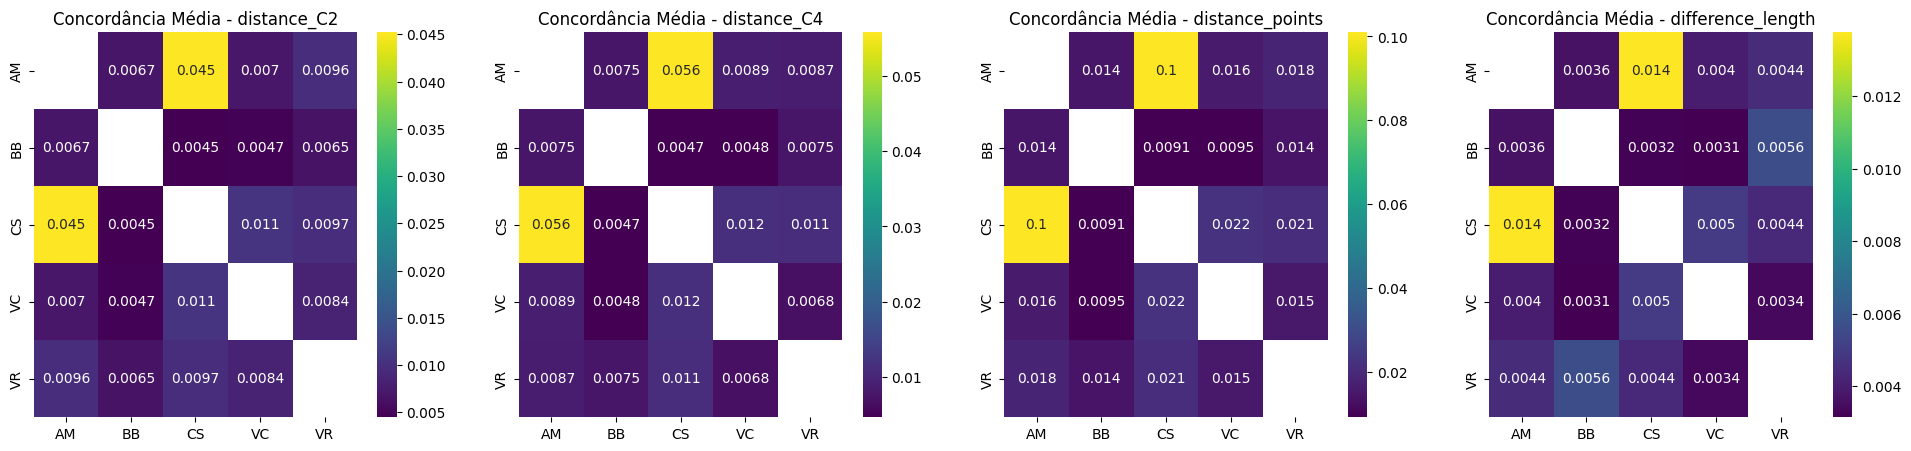

In [8]:
# Matriz de Confusão - Pontos
plot_metric_matrix(dfMetricPoint, ["distance_C2", "distance_C4", "distance_points", "difference_length"])

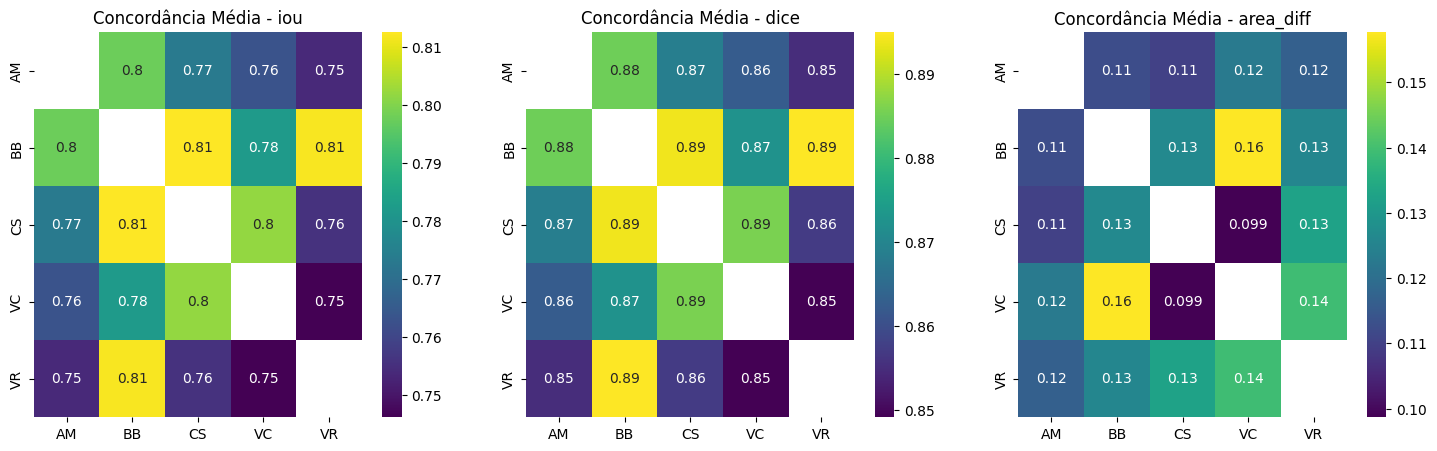

In [9]:
# Matriz de Confusão - Máscara
plot_metric_matrix(dfMetricMask, ["iou", "dice", "area_diff"])

### **Classificando Imagens a serem rotuladas novamente**

In [23]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import cv2


def _save_csvs(relabel: dict, output_csv_dir: str, label_type: str):
    """Salva (ou sobrescreve) o CSV de cada rotulador imediatamente."""
    os.makedirs(output_csv_dir, exist_ok=True)
    for labeler, frames_set in relabel.items():
        rows = [{"video_frame": vf, "rotulo": label_type} for vf in sorted(frames_set)]
        df_out = pd.DataFrame(rows, columns=["video_frame", "rotulo"])
        csv_path = os.path.join(output_csv_dir, f"relabel_{labeler}_{label_type}.csv")
        df_out.to_csv(csv_path, index=False)


def _apply_clahe(frame: np.ndarray, clip_limit: float = 2.0, tile_grid: tuple = (8, 8)) -> np.ndarray:
    """Aplica CLAHE no frame. Suporta imagens grayscale e coloridas (BGR)."""
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    if frame.ndim == 2:
        return clahe.apply(frame)
    else:
        lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
        lab[..., 0] = clahe.apply(lab[..., 0])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


def review_labels(
    video_frame_metadata_df: pd.DataFrame,
    video_folder: str,
    label_type: str,
    output_csv_dir: str = "",
    alpha: float = 0.4,
    skip: int = 20,
    clahe_clip: float = 2.0,
    clahe_tile: tuple = (8, 8),
) -> dict[str, pd.DataFrame]:
    """
    Ferramenta interativa para revisão de rótulos frame a frame.

    - CSVs são salvos/atualizados a cada vez que [1] ou [2] é pressionado.
    - Sessão incremental: carrega CSVs anteriores ao iniciar, retomando
      do primeiro frame ainda não marcado por nenhum rotulador.

    Teclas
    ------
    [1]        Toggle re-rotulagem do rotulador à esquerda (posição 0 no frame)
    [2]        Toggle re-rotulagem do rotulador à direita (posição 1 no frame)
    [←]        Frame anterior
    [→]        Próximo frame
    [ctrl+←]   Volta skip frames
    [ctrl+→]   Avança skip frames
    [c]        Toggle CLAHE no subplot de sobreposição
    [v]        Toggle visibilidade dos rótulos no subplot de sobreposição
    [q]        Encerra a sessão e exibe resumo final
    """
    assert label_type in ("point", "mask"), "label_type deve ser 'point' ou 'mask'"

    all_video_frames = sorted(video_frame_metadata_df["video_frame"].unique())
    n_frames = len(all_video_frames)

    # ── Todos os rotuladores únicos do dataframe ──────────────────────────────
    labelers_ordered: list[str] = video_frame_metadata_df["labeler"].unique().tolist()
    n_labelers = len(labelers_ordered)
    print(f"Rotuladores encontrados ({n_labelers}): {labelers_ordered}")
    print(f"Total de frames: {n_frames}")

    # ── Carrega CSVs existentes (sessão incremental) ──────────────────────────
    def _load_existing_csvs() -> dict[str, set]:
        relabel = {lab: set() for lab in labelers_ordered}
        if not output_csv_dir:
            return relabel
        for labeler in labelers_ordered:
            csv_path = os.path.join(output_csv_dir, f"relabel_{labeler}_{label_type}.csv")
            if os.path.exists(csv_path):
                df_existing = pd.read_csv(csv_path)
                relabel[labeler] = set(df_existing["video_frame"].tolist())
                print(f"  📂 {labeler}: {len(relabel[labeler])} frames carregados de sessão anterior")
            else:
                print(f"  🆕 {labeler}: nenhum CSV anterior encontrado, começando do zero")
        return relabel

    # ── Estado da sessão ──────────────────────────────────────────────────────
    print("\nCarregando sessão anterior (se existir)...")
    state = {
        "idx": 0,
        "relabel": _load_existing_csvs(),
        "fig": None,
        "results": {},
        "clahe_on": False,
        "labels_on": True,   # ← controla visibilidade dos rótulos na sobreposição
    }

    # ── Helpers ───────────────────────────────────────────────────────────────
    def _load_frame(video_id, frame_id) -> np.ndarray:
        path_video = os.path.join(video_folder, f"{video_id}.avi")
        return get_frame_from_video(path_video, int(frame_id))

    def _make_title(labeler: str, video_frame: str) -> str:
        marked = "  ⚑ RE-ROTULAR" if video_frame in state["relabel"].get(labeler, set()) else ""
        return f"{labeler} — {video_frame}{marked}"

    def _clahe_indicator() -> str:
        return "  [CLAHE ON 🔆]" if state["clahe_on"] else ""

    def _draw_points(ax_, df_vf, frame, frame_clahe, colors):
        n = df_vf.shape[0]
        all_pts, all_lab, all_dist = [], [], []
        for i in range(n):
            row = df_vf.iloc[i]
            labeler = row["labeler"]
            ax_[i].imshow(frame)                      # ← sempre frame original
            if row["has_points"]:
                pts = load_points(row["file_path"], "Results.csv")
                dist = math.sqrt(
                    (pts[1][0] - pts[0][0]) ** 2 + (pts[1][1] - pts[0][1]) ** 2
                )
                mid = (pts[0] + pts[1]) / 2
                ax_[i].scatter(pts[:, 0], pts[:, 1], color=colors[i], s=5)
                ax_[i].plot(pts[:, 0], pts[:, 1], color=colors[i], lw=1, alpha=0.3)
                ax_[i].text(
                    mid[0] + 10, mid[1], f"{dist:.1f} px",
                    color=colors[i], fontweight="bold", fontsize=12,
                )
                all_pts.append(pts)
                all_lab.append(labeler)
                all_dist.append(dist)
            else:
                ax_[i].text(
                    frame.shape[1] / 2, frame.shape[0] / 2, "NÃO ROTULADO",
                    color="red", fontweight="bold", fontsize=20, ha="center", va="center",
                )
            ax_[i].axis("off")
            ax_[i].set_title(_make_title(labeler, df_vf["video_frame"].values[0]))

        ax_[-1].imshow(frame_clahe)                   # ← CLAHE apenas na sobreposição
        if state["labels_on"]:
            for i, pts in enumerate(all_pts):
                ax_[-1].scatter(pts[:, 0], pts[:, 1], color=colors[i], s=5,
                                label=f"{all_lab[i]} ({all_dist[i]:.1f} px)")
                ax_[-1].plot(pts[:, 0], pts[:, 1], color=colors[i], lw=1, alpha=0.3)
            ax_[-1].legend(fontsize=8)
        ax_[-1].axis("off")
        ax_[-1].set_title(
            f"Sobreposição de Pontos{_clahe_indicator()}\n"
            f"Frame {state['idx'] + 1} / {n_frames}"
        )

    def _draw_masks(ax_, df_vf, frame, frame_clahe, colors):
        n = df_vf.shape[0]
        all_masks, all_lab = [], []
        for i in range(n):
            row = df_vf.iloc[i]
            labeler = row["labeler"]
            ax_[i].imshow(frame, cmap="gray")          # ← sempre frame original
            if row["has_mask"]:
                path_mask = os.path.join(row["file_path"], "Mask.tif")
                mask = cv2.imread(path_mask, cv2.IMREAD_UNCHANGED)
                if mask is not None and mask.ndim == 3:
                    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
                if mask is None or mask.shape[:2] != frame.shape[:2]:
                    ax_[i].text(
                        frame.shape[1] / 2, frame.shape[0] / 2, "FORMATO\nINCORRETO",
                        color="red", fontweight="bold", fontsize=20, ha="center", va="center",
                    )
                else:
                    rgba = np.zeros((*mask.shape, 4))
                    rgba[..., :3] = plt.cm.colors.to_rgb(colors[i])
                    rgba[..., 3] = (mask > 0) * alpha
                    ax_[i].imshow(rgba)
                    all_masks.append(mask)
                    all_lab.append(labeler)
            else:
                ax_[i].text(
                    frame.shape[1] / 2, frame.shape[0] / 2, "SEM MÁSCARA",
                    color="red", fontweight="bold", fontsize=20, ha="center", va="center",
                )
            ax_[i].axis("off")
            ax_[i].set_title(_make_title(labeler, df_vf["video_frame"].values[0]))

        ax_[-1].imshow(frame_clahe, cmap="gray")       # ← CLAHE apenas na sobreposição
        if state["labels_on"]:
            for i, mask in enumerate(all_masks):
                rgba = np.zeros((*mask.shape, 4))
                rgba[..., :3] = plt.cm.colors.to_rgb(colors[i])
                rgba[..., 3] = (mask > 0) * alpha
                ax_[-1].imshow(rgba)
            patches = [
                mpatches.Patch(color=colors[i], label=all_lab[i], alpha=alpha)
                for i in range(len(all_masks))
            ]
            ax_[-1].legend(handles=patches, fontsize=8)
        ax_[-1].axis("off")
        ax_[-1].set_title(
            f"Sobreposição de Máscaras{_clahe_indicator()}\n"
            f"Frame {state['idx'] + 1} / {n_frames}"
        )

    # ── Renderiza o frame atual ───────────────────────────────────────────────
    def render(idx: int):
        idx = max(0, min(idx, n_frames - 1))

        video_frame = all_video_frames[idx]
        df_vf = (
            video_frame_metadata_df
            .loc[video_frame_metadata_df["video_frame"] == video_frame]
            .reset_index(drop=True)
        )
        colors = generate_color_list(df_vf.shape[0])

        frame = _load_frame(df_vf["video_id"].values[0], df_vf["frame_id"].values[0])
        frame_clahe = _apply_clahe(frame, clahe_clip, clahe_tile) if state["clahe_on"] else frame

        # ── Salva posição atual da janela antes de fechar ─────────────────
        win_geometry = "+0+0"  # posição padrão inicial
        if state["fig"] is not None:
            try:
                win_geometry = state["fig"].canvas.manager.window.wm_geometry()
                # wm_geometry() retorna "WxH+X+Y" — extraímos só "+X+Y"
                if "+" in win_geometry:
                    parts = win_geometry.split("+")
                    win_geometry = f"+{parts[1]}+{parts[2]}"
            except Exception:
                try:
                    geo = state["fig"].canvas.manager.window.geometry()
                    if "+" in geo:
                        parts = geo.split("+")
                        win_geometry = f"+{parts[1]}+{parts[2]}"
                except Exception:
                    pass
            plt.close(state["fig"])

        n_rot = df_vf.shape[0]
        fig, ax = plt.subplots(1, n_rot + 1, figsize=(5 * (n_rot + 1), 5))
        state["fig"] = fig
        state["idx"] = idx

        marked_count = sum(len(v) for v in state["relabel"].values())
        clahe_status  = "ON 🔆" if state["clahe_on"]  else "OFF"
        labels_status = "ON"    if state["labels_on"] else "OFF"
        fig.suptitle(
            f"\n\nFrame {idx + 1} / {n_frames}   |   Marcados para re-rotulagem: {marked_count}   |   CLAHE: {clahe_status}   |   Rótulos sobreposição: {labels_status}\n"
            f"[1] Re-rot. esquerda   [2] Re-rot. direita   [c] Toggle CLAHE   [v] Toggle rótulos\n"
            f"[←] Anterior   [→] Próximo   "
            f"[ctrl+←] -{skip} frames   [ctrl+→] +{skip} frames   "
            f"[q] Encerrar",
            fontsize=10, y=1.06,
        )

        if label_type == "point":
            _draw_points(ax, df_vf, frame, frame_clahe, colors)
        else:
            _draw_masks(ax, df_vf, frame, frame_clahe, colors)

        plt.tight_layout()
        fig.canvas.mpl_connect("key_press_event", on_key)

        plt.show(block=False)

        # ── Restaura a posição salva (ou padrão +0+0 na primeira abertura) ─
        try:
            fig.canvas.manager.window.wm_geometry(win_geometry)
        except AttributeError:
            try:
                x = int(win_geometry.split("+")[1])
                y = int(win_geometry.split("+")[2])
                fig.canvas.manager.window.move(x, y)
            except Exception:
                pass

        fig.canvas.draw()

    # ── Handler de teclado ────────────────────────────────────────────────────
    def on_key(event):
        idx = state["idx"]
        video_frame = all_video_frames[idx]
        save_needed = False

        df_vf = (
            video_frame_metadata_df
            .loc[video_frame_metadata_df["video_frame"] == video_frame]
            .reset_index(drop=True)
        )
        labelers_in_frame = df_vf["labeler"].tolist()

        if event.key == "1" and len(labelers_in_frame) >= 1:
            labeler = labelers_in_frame[0]
            if video_frame in state["relabel"][labeler]:
                state["relabel"][labeler].discard(video_frame)
                print(f"  ✗ {labeler} desmarcado  → {video_frame}")
            else:
                state["relabel"][labeler].add(video_frame)
                print(f"  ✓ {labeler} marcado para re-rotular → {video_frame}")
            save_needed = True

        elif event.key == "2" and len(labelers_in_frame) >= 2:
            labeler = labelers_in_frame[1]
            if video_frame in state["relabel"][labeler]:
                state["relabel"][labeler].discard(video_frame)
                print(f"  ✗ {labeler} desmarcado  → {video_frame}")
            else:
                state["relabel"][labeler].add(video_frame)
                print(f"  ✓ {labeler} marcado para re-rotular → {video_frame}")
            save_needed = True

        elif event.key == "c":
            state["clahe_on"] = not state["clahe_on"]
            status = "ON 🔆" if state["clahe_on"] else "OFF"
            print(f"  🔆 CLAHE {status}")
            render(idx)

        elif event.key == "v":
            state["labels_on"] = not state["labels_on"]
            status = "ON" if state["labels_on"] else "OFF"
            print(f"  🏷 Rótulos na sobreposição: {status}")
            render(idx)

        elif event.key == "right":
            if idx < n_frames - 1:
                render(idx + 1)
            else:
                print("  → Último frame. Pressione [q] para encerrar.")

        elif event.key == "left":
            if idx > 0:
                render(idx - 1)
            else:
                print("  ← Primeiro frame.")

        elif event.key == "ctrl+right":
            new_idx = min(idx + skip, n_frames - 1)
            print(f"  ⏭ Avançando {skip} frames → frame {new_idx + 1}/{n_frames}")
            render(new_idx)

        elif event.key == "ctrl+left":
            new_idx = max(idx - skip, 0)
            print(f"  ⏮ Voltando {skip} frames → frame {new_idx + 1}/{n_frames}")
            render(new_idx)

        elif event.key == "q":
            print("\nSessão encerrada.")
            plt.close("all")
            _finalize()
            return

        if save_needed:
            if output_csv_dir:
                _save_csvs(state["relabel"], output_csv_dir, label_type)
                print(f"    💾 CSVs atualizados em: {output_csv_dir}")
            render(idx)

    # ── Finalização ───────────────────────────────────────────────────────────
    def _finalize():
        results = {}
        print("\n══════════════ RESUMO FINAL ══════════════")
        for labeler, frames_set in state["relabel"].items():
            rows = [{"video_frame": vf, "rotulo": label_type} for vf in sorted(frames_set)]
            df_out = pd.DataFrame(rows, columns=["video_frame", "rotulo"])
            results[labeler] = df_out
            print(f"\n── {labeler} ({len(df_out)} frames) ──")
            print(df_out.to_string(index=False) if not df_out.empty else "  Nenhum frame marcado.")
        state["results"] = results

    # ── Retoma do primeiro frame ainda não marcado por ninguém ───────────────
    already_marked = set().union(*state["relabel"].values())
    remaining = [vf for vf in all_video_frames if vf not in already_marked]

    if remaining:
        start_idx = all_video_frames.index(remaining[0])
        print(f"\nRetomando do frame {start_idx + 1}/{n_frames}: {remaining[0]}")
    else:
        start_idx = 0
        print("\nTodos os frames já foram revisados. Começando do início.")

    render(start_idx)
    plt.show(block=True)

    return state.get("results", {})

In [15]:
import matplotlib
matplotlib.use("TkAgg")

In [25]:
# Para avaliar PONTOS
resultados = review_labels(
    video_frame_metadata_df=video_frame_metadata_df,
    video_folder=videos_dir,
    label_type="point",
    output_csv_dir=r"../relabeling",
)

# Acessar os dataframes diretamente
df_VC  = resultados["VC"]

Rotuladores encontrados (5): ['AM', 'BB', 'CS', 'VC', 'VR']
Total de frames: 1000

Carregando sessão anterior (se existir)...
  📂 AM: 84 frames carregados de sessão anterior
  📂 BB: 20 frames carregados de sessão anterior
  📂 CS: 38 frames carregados de sessão anterior
  📂 VC: 42 frames carregados de sessão anterior
  📂 VR: 39 frames carregados de sessão anterior

Retomando do frame 1/1000: v100_f10
  ⏭ Avançando 20 frames → frame 23/1000
  ⏭ Avançando 20 frames → frame 43/1000
  🏷 Rótulos na sobreposição: OFF
  🏷 Rótulos na sobreposição: ON
  🔆 CLAHE ON 🔆


C:\Users\vinic\AppData\Local\Temp\ipykernel_22136\2281444602.py:258: UserWarning: Glyph 128262 (\N{HIGH BRIGHTNESS SYMBOL}) missing from current font.
  plt.tight_layout()
C:\Users\vinic\AppData\Local\Temp\ipykernel_22136\2281444602.py:274: UserWarning: Glyph 128262 (\N{HIGH BRIGHTNESS SYMBOL}) missing from current font.
  fig.canvas.draw()
c:\Users\vinic\AppData\Local\Programs\Python\Python310\lib\tkinter\__init__.py:839: UserWarning: Glyph 128262 (\N{HIGH BRIGHTNESS SYMBOL}) missing from current font.
  func(*args)


  🔆 CLAHE OFF
  🏷 Rótulos na sobreposição: OFF
  🔆 CLAHE ON 🔆


C:\Users\vinic\AppData\Local\Temp\ipykernel_22136\2281444602.py:258: UserWarning: Glyph 128262 (\N{HIGH BRIGHTNESS SYMBOL}) missing from current font.
  plt.tight_layout()
C:\Users\vinic\AppData\Local\Temp\ipykernel_22136\2281444602.py:274: UserWarning: Glyph 128262 (\N{HIGH BRIGHTNESS SYMBOL}) missing from current font.
  fig.canvas.draw()
c:\Users\vinic\AppData\Local\Programs\Python\Python310\lib\tkinter\__init__.py:839: UserWarning: Glyph 128262 (\N{HIGH BRIGHTNESS SYMBOL}) missing from current font.
  func(*args)


  🏷 Rótulos na sobreposição: ON


C:\Users\vinic\AppData\Local\Temp\ipykernel_22136\2281444602.py:258: UserWarning: Glyph 128262 (\N{HIGH BRIGHTNESS SYMBOL}) missing from current font.
  plt.tight_layout()
C:\Users\vinic\AppData\Local\Temp\ipykernel_22136\2281444602.py:274: UserWarning: Glyph 128262 (\N{HIGH BRIGHTNESS SYMBOL}) missing from current font.
  fig.canvas.draw()
c:\Users\vinic\AppData\Local\Programs\Python\Python310\lib\tkinter\__init__.py:839: UserWarning: Glyph 128262 (\N{HIGH BRIGHTNESS SYMBOL}) missing from current font.
  func(*args)


  🔆 CLAHE OFF
  🏷 Rótulos na sobreposição: OFF

Sessão encerrada.

══════════════ RESUMO FINAL ══════════════

── AM (84 frames) ──
video_frame rotulo
    v10_f23  point
    v10_f24  point
  v113_f106  point
   v114_f12  point
  v114_f120  point
  v115_f150  point
  v125_f113  point
  v128_f169  point
  v128_f236  point
   v133_f37  point
  v134_f124  point
  v137_f112  point
   v13_f150  point
  v141_f187  point
  v141_f204  point
  v142_f181  point
  v143_f186  point
  v148_f150  point
   v14_f130  point
   v150_f13  point
  v154_f188  point
  v155_f117  point
  v155_f206  point
  v155_f234  point
    v15_f26  point
  v166_f182  point
  v169_f117  point
  v169_f208  point
   v169_f81  point
   v173_f48  point
   v173_f82  point
   v175_f16  point
   v177_f31  point
   v183_f30  point
   v184_f88  point
  v185_f116  point
  v185_f142  point
  v186_f190  point
   v186_f24  point
  v188_f139  point
  v188_f158  point
  v189_f222  point
  v189_f223  point
   v189_f72  point
  v190_f156  

In [57]:
# Para avaliar MÁSCARAS
resultados = review_labels(
    video_frame_metadata_df=video_frame_metadata_df,
    video_folder=videos_dir,
    label_type="mask",
    output_csv_dir=r"../relabeling",
)

# Acessar os dataframes diretamente
df_VC  = resultados["VC"]

Rotuladores encontrados (5): ['AM', 'BB', 'CS', 'VC', 'VR']
Total de frames: 1000

Carregando sessão anterior (se existir)...
  🆕 AM: nenhum CSV anterior encontrado, começando do zero
  🆕 BB: nenhum CSV anterior encontrado, começando do zero
  🆕 CS: nenhum CSV anterior encontrado, começando do zero
  🆕 VC: nenhum CSV anterior encontrado, começando do zero
  🆕 VR: nenhum CSV anterior encontrado, começando do zero

Retomando do frame 1/1000: v100_f10


KeyError: 'VC'